In [129]:
#Importing libraries

In [130]:
import pandas as pd
import numpy as np
import re
from matplotlib import pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score,roc_curve,auc,RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB

import warnings
warnings.filterwarnings("ignore")

In [131]:
#reading the datasets

In [132]:
train_news = pd.read_csv('train.csv')
train_news.head()

,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1


In [133]:
test_news = pd.read_csv('test.csv')
test_news.head()

,id,title,author,text
0,20800,"Specter of Trump Loosens Tongues, if Not Purse...",David Streitfeld,"PALO ALTO, Calif. — After years of scorning..."
1,20801,Russian warships ready to strike terrorists ne...,NaN,Russian warships ready to strike terrorists ne...
2,20802,#NoDAPL: Native American Leaders Vow to Stay A...,Common Dreams,Videos #NoDAPL: Native American Leaders Vow to...
3,20803,"Tim Tebow Will Attempt Another Comeback, This ...",Daniel Victor,"If at first you don’t succeed, try a different..."
4,20804,Keiser Report: Meme Wars (E995),Truth Broadcast Network,42 mins ago 1 Views 0 Comments 0 Likes 'For th...


In [134]:
train_news.shape

(20800, 5)

In [135]:
test_news.shape

(5200, 4)

In [136]:
train_news['label'].map({0: 'Real', 1: 'Fake'}) #mapping 0 for real news and 1 for fake news
train_news.head()

,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1


In [137]:
# Data pre-processing

In [138]:
train_news.isnull().sum()

id           0
title      558
author    1957
text        39
label        0
dtype: int64

In [139]:
test_news.isnull().sum()

id          0
title     122
author    503
text        7
dtype: int64

In [140]:
# replacing the null values with empty string
train_news = train_news.fillna(' ')
test_news = test_news.fillna(' ')

In [141]:
train_news.isnull().sum()

id        0
title     0
author    0
text      0
label     0
dtype: int64

In [142]:
test_news.isnull().sum()

id        0
title     0
author    0
text      0
dtype: int64

In [143]:
# Extracting the number of real news and fake news
Y=train_news["label"]
Y.value_counts()

1    10413
0    10387
Name: label, dtype: int64

Text(0, 0.5, 'Count')

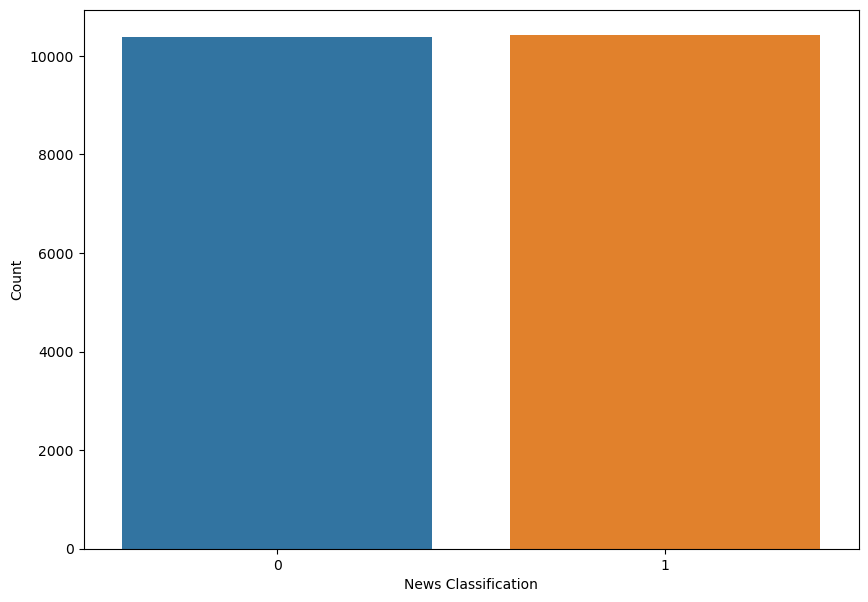

In [144]:
plt.figure(figsize=(10,7))
sns.countplot(x='label', data=train_news)
plt.xlabel('News Classification')
plt.ylabel('Count')

In [145]:
# Basic data exploration 

In [146]:
train_data = train_news[['title', 'text']]
train_data.head()

,title,text
0,House Dem Aide: We Didn’t Even See Comey’s Let...,House Dem Aide: We Didn’t Even See Comey’s Let...
1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Ever get the feeling your life circles the rou...
2,Why the Truth Might Get You Fired,"Why the Truth Might Get You Fired October 29, ..."
3,15 Civilians Killed In Single US Airstrike Hav...,Videos 15 Civilians Killed In Single US Airstr...
4,Iranian woman jailed for fictional unpublished...,Print \nAn Iranian woman has been sentenced to...


In [147]:
test_data= test_news[['title', 'text']]
test_data.head()

,title,text
0,"Specter of Trump Loosens Tongues, if Not Purse...","PALO ALTO, Calif. — After years of scorning..."
1,Russian warships ready to strike terrorists ne...,Russian warships ready to strike terrorists ne...
2,#NoDAPL: Native American Leaders Vow to Stay A...,Videos #NoDAPL: Native American Leaders Vow to...
3,"Tim Tebow Will Attempt Another Comeback, This ...","If at first you don’t succeed, try a different..."
4,Keiser Report: Meme Wars (E995),42 mins ago 1 Views 0 Comments 0 Likes 'For th...


In [148]:
# merging the author name and news title
train_news['content'] = train_news['author']+' '+train_news['title']
test_news['content'] = test_news['author']+' '+test_news['title']

In [149]:
print(train_news['content'])

0        Darrell Lucus House Dem Aide: We Didn’t Even S...
1        Daniel J. Flynn FLYNN: Hillary Clinton, Big Wo...
2        Consortiumnews.com Why the Truth Might Get You...
3        Jessica Purkiss 15 Civilians Killed In Single ...
4        Howard Portnoy Iranian woman jailed for fictio...
                               ...                        
20795    Jerome Hudson Rapper T.I.: Trump a ’Poster Chi...
20796    Benjamin Hoffman N.F.L. Playoffs: Schedule, Ma...
20797    Michael J. de la Merced and Rachel Abrams Macy...
20798    Alex Ansary NATO, Russia To Hold Parallel Exer...
20799              David Swanson What Keeps the F-35 Alive
Name: content, Length: 20800, dtype: object


In [150]:
print(test_news['content'])

0       David Streitfeld Specter of Trump Loosens Tong...
1         Russian warships ready to strike terrorists ...
2       Common Dreams #NoDAPL: Native American Leaders...
3       Daniel Victor Tim Tebow Will Attempt Another C...
4       Truth Broadcast Network Keiser Report: Meme Wa...
                              ...                        
5195    Jody Rosen The Bangladeshi Traffic Jam That Ne...
5196    Sheryl Gay Stolberg John Kasich Signs One Abor...
5197    Mike McPhate California Today: What, Exactly, ...
5198      300 US Marines To Be Deployed To Russian Bor...
5199    Teddy Wayne Awkward Sex, Onscreen and Off - Th...
Name: content, Length: 5200, dtype: object


In [151]:
'''
import re

def stemming(text):
    # Convert text to lowercase
    text = text.lower()
    # Remove special characters and digits using regular expression
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Split the text into words
    words = text.split()
    # Define a dictionary of stopwords to remove
    stopwords_list = {'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 'yours',
                      'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', 'her', 'hers', 'herself',
                      'it', 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which',
                      'who', 'whom', 'this', 'that', 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be',
                      'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an',
                      'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for',
                      'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after',
                      'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under',
                      'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all',
                      'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not',
                      'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don',
                      'should', 'now'}
    # Remove stopwords
    words = [word for word in words if word not in stopwords_list]
    # Perform stemming - a simple stemming algorithm
    stemmed_words = [word[:4] for word in words]  # Simple stemming: Take first 4 characters
    # Join the stemmed words
    processed_text = ' '.join(stemmed_words)
    return processed_text
'''

"\nimport re\n\ndef stemming(text):\n    # Convert text to lowercase\n    text = text.lower()\n    # Remove special characters and digits using regular expression\n    text = re.sub(r'[^a-zA-Z\\s]', '', text)\n    # Split the text into words\n    words = text.split()\n    # Define a dictionary of stopwords to remove\n    stopwords_list = {'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 'yours',\n                      'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', 'her', 'hers', 'herself',\n                      'it', 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which',\n                      'who', 'whom', 'this', 'that', 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be',\n                      'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an',\n                      'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for',\n       

In [152]:
# stemming

In [153]:
ps=PorterStemmer()

In [154]:
def stemming(content):
    # Removes special character and coverting to lower case
    content = re.sub('[^a-zA-Z]', ' ', content.lower())
    content = content.split()
    # Stemming the words and removing the stopwords
    content = [ps.stem(word) for word in content if word not in stopwords.words('english')]
   # Joining the stemmed words
    content = ' '.join(content)
    return content 

In [155]:
#import nltk
#nltk.download('stopwords')

In [156]:
print(stopwords.words('english'))

['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', '

In [157]:
train_news['content'] = train_news['content'].apply(stemming)

In [158]:
print(train_news['content'])

0        darrel lucu hous dem aid even see comey letter...
1        daniel j flynn flynn hillari clinton big woman...
2                   consortiumnew com truth might get fire
3        jessica purkiss civilian kill singl us airstri...
4        howard portnoy iranian woman jail fiction unpu...
                               ...                        
20795    jerom hudson rapper trump poster child white s...
20796    benjamin hoffman n f l playoff schedul matchup...
20797    michael j de la merc rachel abram maci said re...
20798    alex ansari nato russia hold parallel exercis ...
20799                            david swanson keep f aliv
Name: content, Length: 20800, dtype: object


In [159]:
test_news['content'] = test_news['content'].apply(stemming)

In [160]:
print(test_news['content'])

0       david streitfeld specter trump loosen tongu pu...
1       russian warship readi strike terrorist near al...
2       common dream nodapl nativ american leader vow ...
3       daniel victor tim tebow attempt anoth comeback...
4        truth broadcast network keiser report meme war e
                              ...                        
5195    jodi rosen bangladeshi traffic jam never end n...
5196    sheryl gay stolberg john kasich sign one abort...
5197    mike mcphate california today exactli sushi ne...
5198                us marin deploy russian border norway
5199        teddi wayn awkward sex onscreen new york time
Name: content, Length: 5200, dtype: object


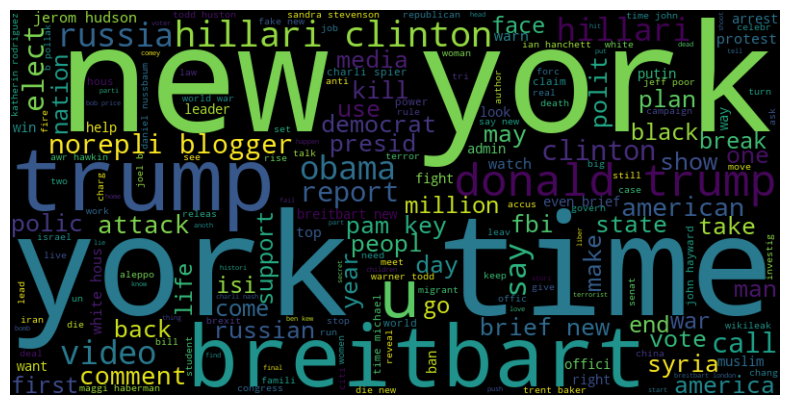

In [161]:
# word cloud for train_news
from wordcloud import WordCloud
all_text = ' '.join(train_news['content'])
# Create WordCloud
wordcloud = WordCloud(width=800, height=400,background_color="black").generate(all_text)
# Plot WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

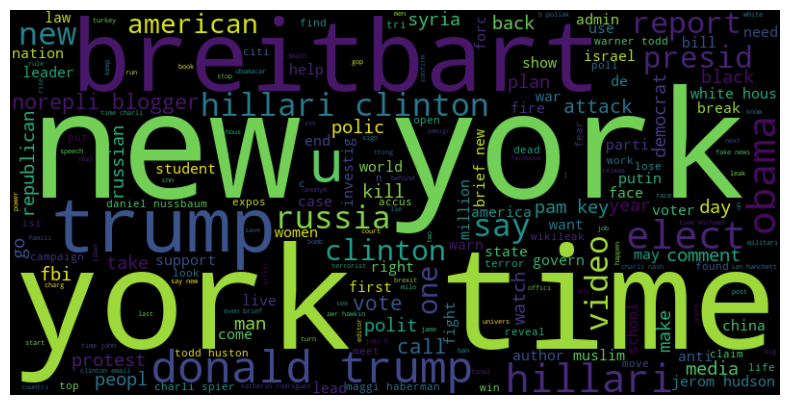

In [162]:
# word cloud for test_news
from wordcloud import WordCloud
all_text_test = ' '.join(test_news['content'])
# Create WordCloud
wordcloud = WordCloud(width=800, height=400,background_color="black").generate(all_text_test)
# Plot WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [163]:
# Converting the textual data into numerical data

In [164]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer with desired parameters
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), smooth_idf=False)

# Fit and transform the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(train_news['content'].values)

# Transform the test data using the same vectorizer
X_test_tfidf = tfidf_vectorizer.transform(test_news['content'].values)


In [165]:
print(X_train_tfidf)

  (0, 19135)	0.26204610779537446
  (0, 61767)	0.20942895539914191
  (0, 68541)	0.26204610779537446
  (0, 24033)	0.20942895539914191
  (0, 107521)	0.26204610779537446
  (0, 39622)	0.26204610779537446
  (0, 2404)	0.26204610779537446
  (0, 31304)	0.26204610779537446
  (0, 56545)	0.26204610779537446
  (0, 71224)	0.26204610779537446
  (0, 29293)	0.2069058767998508
  (0, 126507)	0.16065154416621358
  (0, 19128)	0.20942895539914191
  (0, 61763)	0.13962883498581546
  (0, 68519)	0.16481028088634128
  (0, 23972)	0.13905863904685986
  (0, 107509)	0.14457901170299542
  (0, 39565)	0.13140699813952156
  (0, 2381)	0.15224944201738022
  (0, 31300)	0.1524950554325566
  (0, 56502)	0.12317466738506137
  (0, 71217)	0.2069058767998508
  (0, 29292)	0.20462347457870128
  (1, 17213)	0.2642629732572119
  (1, 134860)	0.3262626198469155
  :	:
  (20797, 122072)	0.04792448258711049
  (20797, 136631)	0.04884318591885717
  (20797, 81530)	0.04721263066890577
  (20798, 40286)	0.318507387984356
  (20798, 87230)	0.31850

In [166]:
print(X_test_tfidf)

  (0, 136689)	0.07821586560992565
  (0, 136631)	0.07804578960081782
  (0, 129065)	0.2840329618303142
  (0, 124584)	0.09713566268548707
  (0, 122852)	0.3495815953091954
  (0, 122072)	0.07657780741279699
  (0, 116583)	0.3639803922800431
  (0, 116433)	0.30682635047740936
  (0, 110733)	0.2924275535065617
  (0, 110732)	0.2924275535065617
  (0, 95730)	0.3495815953091954
  (0, 81893)	0.07805710269515473
  (0, 81530)	0.07544034997651426
  (0, 70720)	0.3314412564809504
  (0, 29586)	0.30682635047740936
  (0, 29524)	0.18431107300714653
  (1, 132177)	0.3307203756027517
  (1, 120657)	0.23605692140289733
  (1, 116570)	0.361386620632955
  (1, 116505)	0.2364022766172983
  (1, 104332)	0.3529481943853309
  (1, 104161)	0.2028071067458685
  (1, 97789)	0.38759876670419646
  (1, 97751)	0.2553743712066612
  (1, 80897)	0.38759876670419646
  :	:
  (5197, 76556)	0.23681906500152114
  (5197, 74722)	0.3161685634689184
  (5197, 74717)	0.3064425307903166
  (5197, 40045)	0.3811844870360182
  (5197, 16526)	0.31007683

In [167]:
# Spliiting the data into training and testing dataset

In [168]:
X_train, X_test, Y_train, Y_test = train_test_split(X_train_tfidf, Y, test_size = 0.2, stratify=Y, random_state=42)

In [169]:
print(f"Number of Training dataset: {X_train.shape[0]}\nNumber of Testing dataset: {X_test.shape[0]}")

Number of Training dataset: 16640
Number of Testing dataset: 4160


In [170]:
def kfolds(model, model_name):
    model = cross_val_score(model, X_train_tfidf,Y, cv=10)
    model_score = np.average(model)
    print(f"{model_name} score on cross validation: {model_score}")
    return model_score

def train(model, model_name):
    model.fit(X_train, Y_train)
    y_pred=model.predict(X_test)
    accuracy=accuracy_score(Y_test,y_pred)
    print(f"{model_name} acuracy score : {accuracy}")
    return accuracy
    
def conf_matrix(model):
    Y_pred = model.predict(X_test)
    cm = confusion_matrix(Y_test, Y_pred)
    plt.figure(figsize=(8,5))
    sns.heatmap(cm, annot=True, fmt='.2f',xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake']);
    
def class_report(model):
    Y_pred = model.predict(X_test)
    print(classification_report(Y_test, Y_pred))

def roc(model, model_name):
    Y_pred_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(Y_test, Y_pred_prob)
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=model_name + ' (AUC = {:.2f})'.format(auc_score))
    plt.plot([0, 1], [0, 1], color="darkorange", lw=2, linestyle="--")
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - {}'.format(model_name))
    plt.legend(loc='lower right')
    plt.show()

In [171]:
# Logistic Regression

In [172]:
log_model = LogisticRegression()
train(log_model, "Logistic Regression")

Logistic Regression acuracy score : 0.96875


0.96875

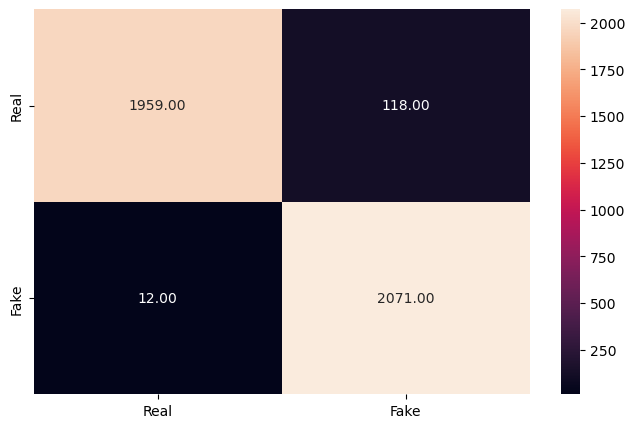

In [173]:
conf_matrix(log_model)

In [174]:
class_report(log_model)

              precision    recall  f1-score   support

           0       0.99      0.94      0.97      2077
           1       0.95      0.99      0.97      2083

    accuracy                           0.97      4160
   macro avg       0.97      0.97      0.97      4160
weighted avg       0.97      0.97      0.97      4160



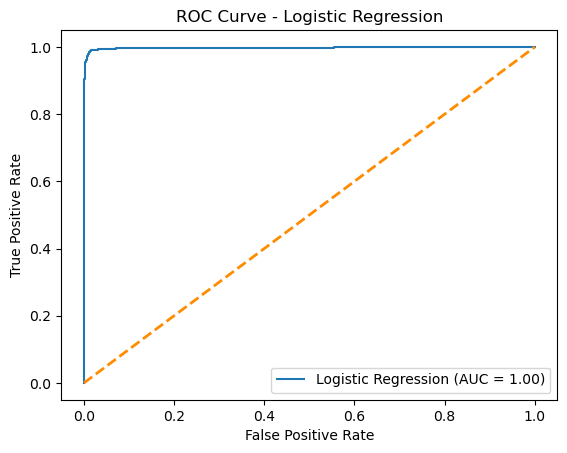

In [175]:
roc(log_model, "Logistic Regression")

In [176]:
# Decision Tree Classifier

In [177]:
dt_model = DecisionTreeClassifier()
train(dt_model, "Decision_Tree")

Decision_Tree acuracy score : 0.9942307692307693


0.9942307692307693

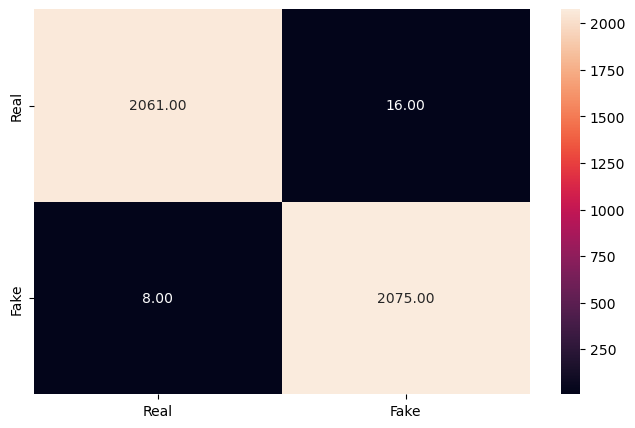

In [178]:
conf_matrix(dt_model)

In [179]:
class_report(dt_model)

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2077
           1       0.99      1.00      0.99      2083

    accuracy                           0.99      4160
   macro avg       0.99      0.99      0.99      4160
weighted avg       0.99      0.99      0.99      4160



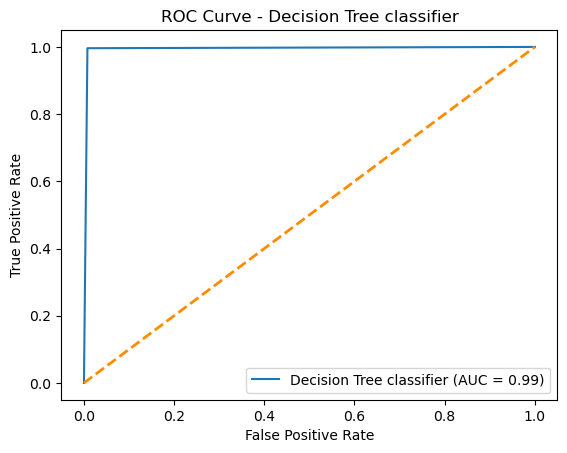

In [180]:
roc(dt_model, "Decision Tree classifier")

In [181]:
# Random Forest Classifier

In [182]:
rf_model = RandomForestClassifier()
train(rf_model, "Random_Forest")

Random_Forest acuracy score : 0.9925480769230769


0.9925480769230769

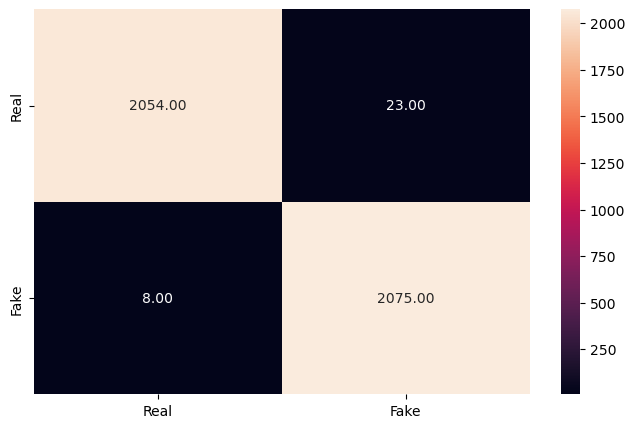

In [183]:
conf_matrix(rf_model)

In [184]:
class_report(rf_model)

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2077
           1       0.99      1.00      0.99      2083

    accuracy                           0.99      4160
   macro avg       0.99      0.99      0.99      4160
weighted avg       0.99      0.99      0.99      4160



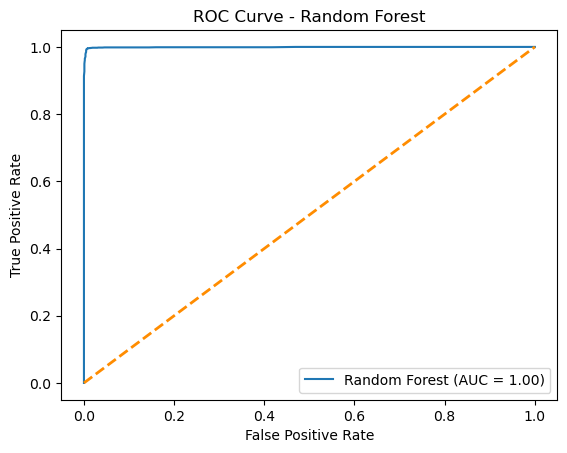

In [185]:
roc(rf_model, "Random Forest")

In [186]:
# Naive bayes

In [187]:
naive_bayes = MultinomialNB()
kfolds(naive_bayes, "Naive_Bayes")
train(naive_bayes, "Naive_Bayes")

Naive_Bayes score on cross validation: 0.9643750000000001
Naive_Bayes acuracy score : 0.9632211538461538


0.9632211538461538

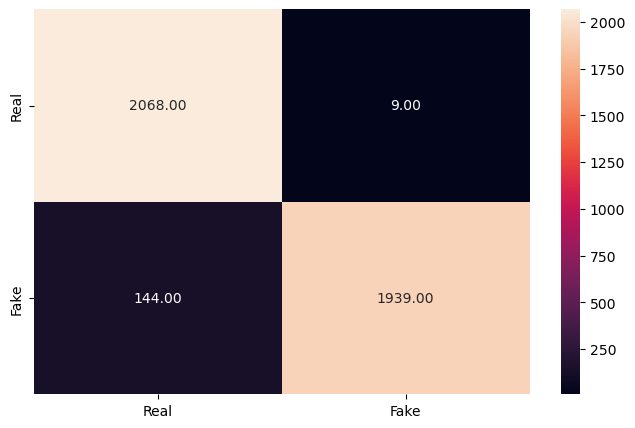

In [188]:
conf_matrix(naive_bayes)

In [189]:
class_report(naive_bayes)

              precision    recall  f1-score   support

           0       0.93      1.00      0.96      2077
           1       1.00      0.93      0.96      2083

    accuracy                           0.96      4160
   macro avg       0.97      0.96      0.96      4160
weighted avg       0.97      0.96      0.96      4160



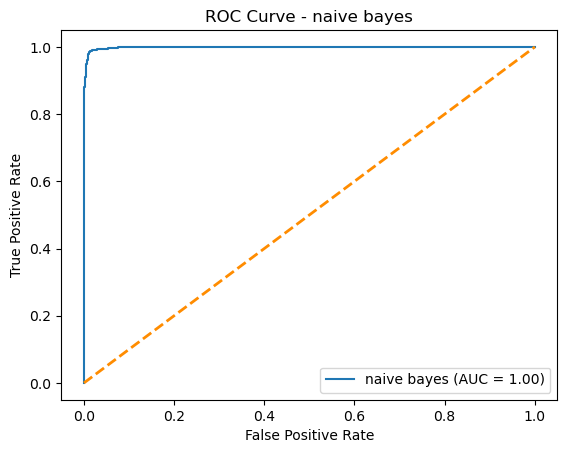

In [190]:
roc(naive_bayes,"naive bayes")

In [191]:
# K nearest neighbours

In [192]:
knn = KNeighborsClassifier()
train(knn, "KNN")

KNN acuracy score : 0.5033653846153846


0.5033653846153846

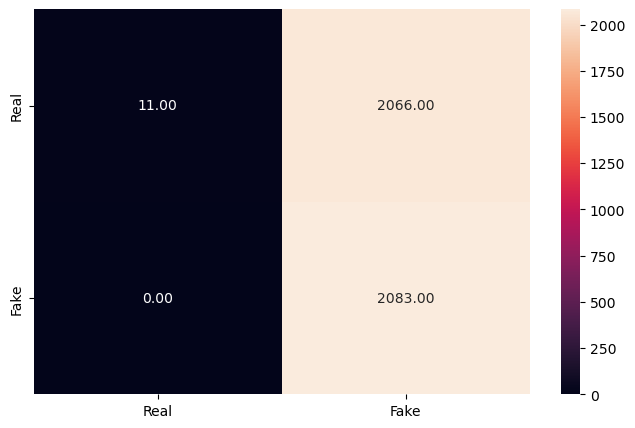

In [193]:
conf_matrix(knn)

In [194]:
class_report(knn)

              precision    recall  f1-score   support

           0       1.00      0.01      0.01      2077
           1       0.50      1.00      0.67      2083

    accuracy                           0.50      4160
   macro avg       0.75      0.50      0.34      4160
weighted avg       0.75      0.50      0.34      4160



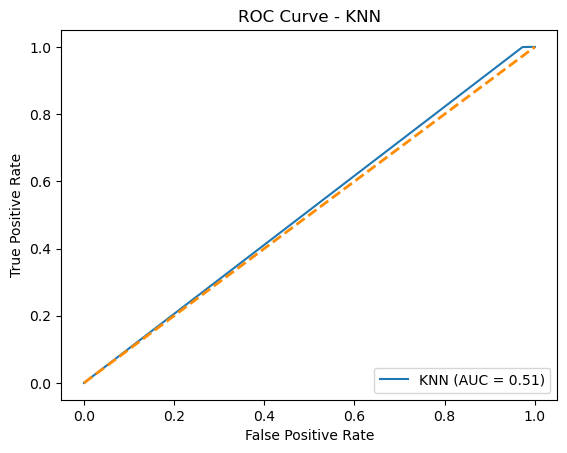

In [195]:
roc(knn, "KNN")

In [196]:
# Comparision of the accuracy of the models

Logistic Regression acuracy score : 0.96875
DecisionTreeClassifier acuracy score : 0.9939903846153846
Naive_Bayes acuracy score : 0.9632211538461538
RandomForestClassifier acuracy score : 0.9925480769230769


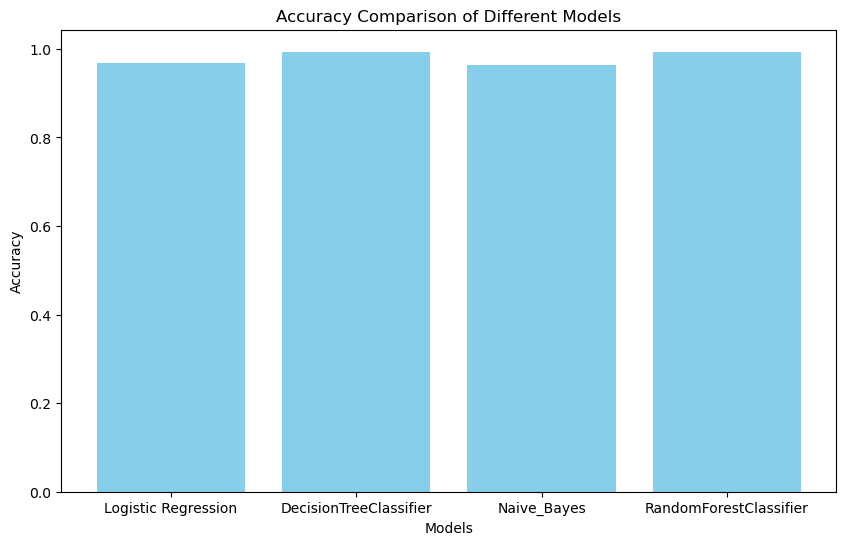

In [197]:
models = [
    (log_model, 'Logistic Regression'),
    (dt_model, 'DecisionTreeClassifier'),
    (naive_bayes, 'Naive_Bayes'),
    (rf_model, 'RandomForestClassifier'),   
]
model_names=[]
accuracies=[]

for model, model_name in models:  
    accuracy = train(model, model_name)
    model_names.append(model_name)  
    accuracies.append(accuracy) 
    
plt.figure(figsize=(10, 6))
plt.bar(model_names, accuracies, color='skyblue')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison of Different Models')
plt.show()

In [198]:
# Making predictions

In [199]:
predictions = dt_model.predict(X_test_tfidf)
predicted_labels = pd.Series(predictions).map({0: "real", 1: "fake"})
test_ID = test_news.id
test_text= test_news.text
dt = pd.DataFrame({'text' : test_text, 'label' : predictions,'real/fake':predicted_labels})

In [200]:
dt

,text,label,real/fake
0,"PALO ALTO, Calif. — After years of scorning...",0,real
1,Russian warships ready to strike terrorists ne...,1,fake
2,Videos #NoDAPL: Native American Leaders Vow to...,1,fake
3,"If at first you don’t succeed, try a different...",0,real
4,42 mins ago 1 Views 0 Comments 0 Likes 'For th...,1,fake
...,...,...,...
5195,Of all the dysfunctions that plague the world’...,0,real
5196,WASHINGTON — Gov. John Kasich of Ohio on Tu...,0,real
5197,Good morning. (Want to get California Today by...,0,real
5198,« Previous - Next » 300 US Marines To Be Deplo...,1,fake


In [201]:
# For generating random integer
from random import randint

# Randomly select a row index
row_index = randint(0, train_news.shape[0]-1)

# Get the sample news
sample_news = train_news.iloc[row_index]

# Print the actual label
actual_label = sample_news['label']
print('Actual Label: {}'.format(actual_label))

# Make a prediction using decision tree model
predicted_label = dt_model.predict(X_train_tfidf[row_index])
print("predicted_label",predicted_label)
# Print the news
print('News: {}'.format(sample_news['text']))

# Print the predicted label
if predicted_label == 0:
  print('Prediction: This is a REAL news!')
else:
  print('Prediction: This is a FAKE news!')


Actual Label: 1
predicted_label [1]
News:   Is Hillary Clinton’s Entourage Involved In A Satanic Pedophile Ring? Is Hillary Clinton’s Entourage Involved In A Satanic Pedophile Ring? Jean-Batave Poqueliche 
Jean-Batave is a martial artist from the viking stronghold of Normandy, France. He travels the world looking for new fighting techniques and new beautiful women. Eastern Europe taught him everything he knows and is his second home. His column runs every Thursday. November 8, 2016 News 
The latest batch of the Podesta emails shared by Wikileaks add a darker dimension (if it was even possible) to the sordid culture of corruption, lies and depravity that surrounds Hillary Clinton, explaining why the FBI has been calling her for quite some time now, the “Antichrist personified” . 
It is a possibility that Hellary’s clique attends and organizes Satanic rituals, involving mock-up scenes of cannibalism and sexual abuse involving children. 
One of the emails directed at Tony Podesta (John Po

In [202]:
from random import randint

# Randomly select a row index
row_index = randint(0, train_news.shape[0]-1)

# Get the sample news
sample_news = train_news.iloc[row_index]

# Print the actual label
actual_label = sample_news['label']
print('Actual Label: {}'.format(actual_label))

# Make a prediction using decision tree model
predicted_label = dt_model.predict(X_train_tfidf[row_index])
print("predicted_label",predicted_label)
# Print the news
print('News: {}'.format(sample_news['text']))

# Print the predicted label
if predicted_label == 0:
  print('Prediction: This is a REAL news!')
else:
  print('Prediction: This is a FAKE news!')


Actual Label: 0
predicted_label [0]
News:    James Franco says he took the election of Donald Trump “really badly,” and has been suffering psychologically as of late. [“I mean, I’ve been reacting really badly!” Franco told the Daily Beast in an interview to promote his latest film, I Am Michael. “I’ve spiraled into a depression and I’ve been questioning everything that I am, and how I’ve been doing things. ”  The    star endorsed Hillary Clinton in October via a parody video of the famous Dos Equis beer “Most Interesting Man in the World” commercials. “She’s the most interesting woman in the world,” Franco says in the ad, which first appeared on his personal Instagram page. Today, the   actor admits that “it’s been a rough few months. ” It’s also been a busy year, so far, for Franco. The budding producer is either filming or in the post production phase of more than a dozen films. Franco is currently making the media rounds to promoting his bio drama I Am Michael, which follows a gay a

In [205]:
def output_label(n):  
    if n == 1:  
        return "Fake News"  
    elif n == 0:  
        return "Real News"  
     
def manual_testing(news):  
    testing_news = {"text":[news]}  
    new_def_test = pd.DataFrame(testing_news)  
    new_def_test["text"] = new_def_test["text"].apply(stemming)  
    new_x_test = new_def_test["text"]  
    new_xv_test = tfidf_vectorizer.transform(new_x_test)  
    pred_log = log_model.predict(new_xv_test)  
    pred_dt = dt_model.predict(new_xv_test)  
    pred_rf = rf_model.predict(new_xv_test)  
    pred_nb = naive_bayes.predict(new_xv_test)    
    return print("\n\nLogistic Regression Prediction: {} \nDecision Tree Classifier Prediction: {} \nRandom Forest Prediction: {} \nNaive Bayes Prediction: {}".format(output_label(pred_log[0]),output_label(pred_dt[0]),  
                                                                                                              output_label(pred_rf[0]),  
                                                                                                              output_label(pred_nb[0])))  
user_input = input("Enter the news text: ")
manual_testing(user_input)

Enter the news text: In these trying times, Jackie Mason is the Voice of Reason. [In this week’s exclusive clip for Breitbart News, Jackie discusses the looming threat of North Korea, and explains how President Donald Trump could win the support of the Hollywood left if the U. S. needs to strike first.  “If he decides to bomb them, the whole country will be behind him, because everybody will realize he had no choice and that was the only thing to do,” Jackie says. “Except the Hollywood left. They’ll get nauseous. ” “[Trump] could win the left over, they’ll fall in love with him in a minute. If he bombed them for a better reason,” Jackie explains. “Like if they have no transgender toilets. ” Jackie also says it’s no surprise that Hollywood celebrities didn’t support Trump’s strike on a Syrian airfield this month. “They were infuriated,” he says. “Because it might only save lives. That doesn’t mean anything to them. If it only saved the environment, or climate change! They’d be the happi